<a href="https://colab.research.google.com/github/SmitSutariya0205/PyTorch-Autoencoders/blob/main/VAE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets,transforms
import torch.optim as optim
from torch.utils.data import DataLoader

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
transform=transforms.ToTensor()
train_dataset=datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 999kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.82MB/s]


In [4]:
train_loader=DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

In [11]:
class ConvVAE(nn.Module):
  def __init__(self,latent_dim=20):
    super().__init__()
    self.enc_conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=4,
        stride=2,
        padding=1
    )
    self.enc_conv2=nn.Conv2d(
        32,
        64,
        kernel_size=4,
        stride=2,
        padding=1
    )
    self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
    self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
    self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
    self.dec_conv1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=4,
            stride=2,
            padding=1
        )
    self.dec_conv2 = nn.ConvTranspose2d(
            32,
            1,
            kernel_size=4,
            stride=2,
            padding=1
        )

  def encode(self,x):
    x=F.relu(self.enc_conv1(x))
    x=F.relu(self.enc_conv2(x))
    x =x.view(x.size(0),-1)
    mu=self.fc_mu(x)
    logvar=self.fc_logvar(x)
    return mu,logvar
  def reparameterize(self,mu,logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    z = mu+eps*std
    return z
  def decode(self,z):
    x=self.fc_decode(z)
    x=x.view(-1,64,7,7)
    x=F.relu(self.dec_conv1(x))
    x=torch.sigmoid(self.dec_conv2(x))
    return x
  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    x_recon = self.decode(z)
    return x_recon, mu, logvar

In [12]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL divergence
    kl_loss = 0.5 * torch.sum(mu**2 + logvar.exp() - logvar - 1)
    return recon_loss + kl_loss

In [15]:
model = ConvVAE(latent_dim=20).to(device)
optimizer=optim.Adam(model.parameters(),lr = 1e-3)

In [16]:
epochs = 16
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_reconstructed, mu, logvar = model(x)
        loss = vae_loss(
            x_reconstructed,
            x,
            mu,
            logvar
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader.dataset)

    print(
        f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}"
    )

Epoch [1/16], Loss: 47.6605
Epoch [2/16], Loss: 33.4492
Epoch [3/16], Loss: 31.9304
Epoch [4/16], Loss: 31.3261
Epoch [5/16], Loss: 30.9272
Epoch [6/16], Loss: 30.6037
Epoch [7/16], Loss: 30.3614
Epoch [8/16], Loss: 30.1435
Epoch [9/16], Loss: 29.9662
Epoch [10/16], Loss: 29.7745
Epoch [11/16], Loss: 29.6269
Epoch [12/16], Loss: 29.4849
Epoch [13/16], Loss: 29.3723
Epoch [14/16], Loss: 29.3006
Epoch [15/16], Loss: 29.1716
Epoch [16/16], Loss: 29.0984


In [18]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x_recon, _, _ = model(x)
x = x.cpu()
x_recon = x_recon.cpu()

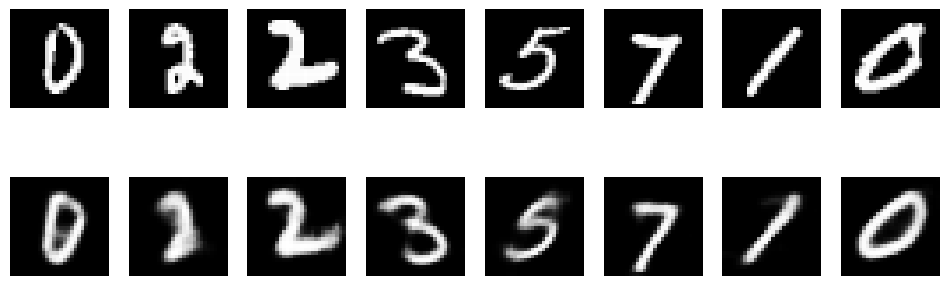

In [21]:
import matplotlib.pyplot as plt

n = 8
plt.figure(figsize=(12,4))

for i in range(n):

    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [29]:
# lets take few random latent vectors and check their reconstruction
with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    samples = model.decode(z).cpu()

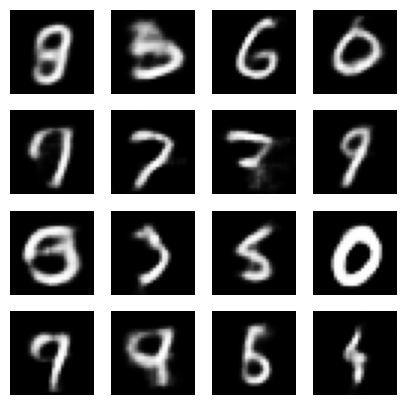

In [30]:
plt.figure(figsize=(5,5))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()